# 08 — Team Comparison at Equal Transaction Costs

## Purpose

Four workstreams in the team built event-driven strategies on ES futures, each reported with **different cost assumptions**, **different evaluation periods** and **different Sharpe methods**:

| Workstream | Signal | Reported cost assumption |
|---|---|---|
| **Reza** (this project) | Macro surprise (actual − consensus), entry at T+1 | 2 ticks + $4.50 per round trip |
| **Jack Duncan** | DTW price-path pattern, five windows per release | ¼ tick per side, no commission |
| **Hoshea Zeng** | DTW "event game" factor (FOMC, JOLTS, PCE, Jobless Claims) | none (IC only) |
| **Aaryen Mehta** | Surprise + DTW + momentum classifier | none, entry at the release instant |

This notebook re-prices **every workstream's own trades** under **the same four cost scenarios**, over **the same evaluation window (2019–2026)**, with **the same Sharpe method** (monthly returns, √12).

| Scenario | Round-trip cost per ES contract |
|---|---|
| Gross | $0 |
| Jack: ¼ tick per side | ½ tick = $6.25 (~0.2 bps) |
| ½ tick per side | 1 tick = $12.50 (~0.4 bps) |
| Ours: 2 ticks + $4.50 | $29.50 (~1–1.6 bps) |

**Inputs (each person's own saved outputs):**
- Reza: `results/nb05_trade_log.csv`, `results/nb07_portfolio_trade_log.csv`
- Hoshea: `dtw_simple_generalized_best_factor.parquet` (his best grid setting; one row per "game")
- Aaryen: `backtest_predictions_{10,30,60}min.parquet` (his walk-forward positions)
- Jack: his trade log is not saved in the repo, so his slide strategy is **rebuilt from its specification** (`src/team_replication.py`, Section 5b), checked against his slide numbers, and then re-priced like everyone else.

The Hoshea and Aaryen files were copied into `data/team_inputs/`.

## 1. Setup

In [1]:
from pathlib import Path
import sys, importlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"
TEAM_IN = PROJECT_ROOT / "data" / "team_inputs"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import src.state_conditioning as sc
importlib.reload(sc)

EVAL_START, EVAL_END = "2019-01-01", "2026-06-30"
N_YEARS = (pd.Timestamp(EVAL_END) - pd.Timestamp(EVAL_START)).days / 365.25
MONTHS = pd.period_range(EVAL_START[:7], EVAL_END[:7], freq="M")
SPECS = {"ES": (0.25, 50.0), "NQ": (0.25, 20.0), "ZN": (1 / 64, 1000.0)}   # tick, $ per point
SCENARIOS = {                      # (ticks per round trip, commission $ per round trip)
    "gross": (0.0, 0.0),
    "Jack: 1/4 tick per side": (0.5, 0.0),
    "1/2 tick per side": (1.0, 0.0),
    "ours: 2 ticks + $4.50": (2.0, 4.5),
}
N_NULL = 1000

for f in ["dtw_simple_generalized_best_factor.parquet", "aaryen_backtest_predictions_30min.parquet"]:
    print(f, (TEAM_IN / f).exists())

dtw_simple_generalized_best_factor.parquet True
aaryen_backtest_predictions_30min.parquet True


## 2. A Common Scoring Function

Every workstream is turned into the same trade log: `entry_time`, `position` (signed, possibly fractional), `ret_bps` (the market return over the trade), `price` (for costs) and `market`. Net P&L = position × return − |position| × cost.

In [2]:
def cost_bps(price, market, ticks_rt, commission_rt):
    tick, pv = SPECS[market]
    return (ticks_rt * tick + commission_rt / pv) / np.asarray(price, float) * 1e4

def score(t, scenario, label, with_null=False, seed=3):
    ticks, comm = SCENARIOS[scenario]
    t = t[(t["entry_time"] >= pd.Timestamp(EVAL_START, tz="UTC")) &
          (t["entry_time"] <= pd.Timestamp(EVAL_END, tz="UTC") + pd.Timedelta(days=1))].dropna(subset=["ret_bps"]).copy()
    c = np.zeros(len(t))
    for m, g in t.groupby("market"):
        c[t["market"].eq(m).to_numpy()] = cost_bps(g["price"], m, ticks, comm)
    t["cost"] = c
    t["net"] = t["position"] * t["ret_bps"] - t["position"].abs() * t["cost"]
    traded = t["position"] != 0
    per = t["entry_time"].dt.tz_convert(None).dt.to_period("M")

    def sharpe_of(net):
        m = (net / 1e4).groupby(per).sum().reindex(MONTHS, fill_value=0.0)
        return m.mean() / m.std(ddof=1) * np.sqrt(12) if m.std(ddof=1) > 0 else np.nan, m

    sh, m = sharpe_of(t["net"])
    ex = m[m.index.year != 2022]
    cum = t["net"].cumsum() / 100
    out = dict(book=label, scenario=scenario,
               trades_per_year=traded.sum() / N_YEARS,
               net_bps_per_unit=t["net"].sum() / t["position"].abs().sum() if traded.any() else np.nan,
               hit_rate=(t.loc[traded, "net"] > 0).mean(),
               total_net_pct=t["net"].sum() / 100,
               sharpe=sh, sharpe_ex_2022=ex.mean() / ex.std(ddof=1) * np.sqrt(12),
               max_dd_pct=(cum - cum.cummax()).min())
    if with_null:
        rng = np.random.default_rng(seed)
        base = t["position"].abs().to_numpy() * t["ret_bps"].to_numpy()
        costs = t["position"].abs().to_numpy() * t["cost"].to_numpy()
        null = [sharpe_of(pd.Series(rng.choice([-1.0, 1.0], len(t)) * base - costs, index=t.index))[0] for _ in range(N_NULL)]
        out["p_random_sign"] = float(np.nanmean(np.array(null) >= sh))
    return out

## 3. Reza: Surprise Strategies (ES, NQ, ES+NQ)

In [3]:
books = {}
def from_log(df, strategy, market=None, label=None):
    d = df[df["strategy"] == strategy]
    if market is not None:
        d = d[d["market"] == market]
    mk = d["market"] if "market" in d else pd.Series("ES", index=d.index)
    # our logs store cost_bps at 2 ticks + $4.50; recover the price from it
    tick_pv = mk.map(SPECS)
    price = [(2 * tp[0] + 4.5 / tp[1]) / c * 1e4 if c > 0 else np.nan for tp, c in zip(tick_pv, d["cost_bps"])]
    return pd.DataFrame({"entry_time": pd.to_datetime(d["timestamp_utc"], utc=True) + pd.Timedelta(minutes=1),
                         "position": d["position"].to_numpy(), "ret_bps": d["ret_bps"].to_numpy(),
                         "price": price, "market": mk.to_numpy()})

log5 = pd.read_csv(RESULTS_DIR / "nb05_trade_log.csv")
log7 = pd.read_csv(RESULTS_DIR / "nb07_portfolio_trade_log.csv")
books["Reza · ES · CPI surprise model"] = from_log(log5, "CPI · surprise model")
books["Reza · ES · All releases (surprise)"] = from_log(log5, "All · naive")
books["Reza · NQ · All releases (surprise)"] = from_log(log7, "3-market · All · naive", market="NQ")
es_nq = log7[(log7["strategy"] == "2-market (ES+NQ) · All · naive")]
books["Reza · ES+NQ · All releases (surprise)"] = from_log(es_nq, "2-market (ES+NQ) · All · naive")
for k, v in books.items():
    print(f"{k:<42s} {int((v.position != 0).sum()):>5d} trades")

Reza · ES · CPI surprise model                67 trades
Reza · ES · All releases (surprise)          744 trades
Reza · NQ · All releases (surprise)          745 trades
Reza · ES+NQ · All releases (surprise)      1489 trades


## 4. Hoshea: DTW Event-Game Factor

Each "game" is an anchor $T_0 \in \{T-60, T-30, T, T+30, T+60\}$ around a release. The DTW path runs over $[T_0, T_0+60]$ and the trade is the next 30 minutes, $[T_0+60, T_0+90]$. Following Jack's independent check (`jack/verify_teammate_claims.py`), the trade is the **sign of the factor**, one ES contract.

Note: this is Hoshea's **best grid setting, chosen on the full sample** (event group FOMC + JOLTS + PCE + Jobless Claims), so it contains some in-sample selection.

In [4]:
hb = pd.read_parquet(TEAM_IN / "dtw_simple_generalized_best_factor.parquet")
print("columns:", list(hb.columns))
hb["t0_utc"] = pd.to_datetime(hb["t0_utc"], utc=True)
entry = hb["t0_utc"] + pd.Timedelta(minutes=60)

es_adj = sc.build_adjusted_log_price(sc.load_es_minute(RAW_DIR / "ES_1m_2010_2026_full.parquet"))[0]
idx_ns = (es_adj.index.as_unit("ns") if hasattr(es_adj.index, "as_unit") else es_adj.index).asi8
close = es_adj["close"].to_numpy(); lp = es_adj["logp_adj"].to_numpy()
def asof(ts, arr):
    ts = pd.DatetimeIndex(ts); ts = ts.as_unit("ns") if hasattr(ts, "as_unit") else ts
    pos = np.searchsorted(idx_ns, ts.asi8, side="right") - 1
    ok = (pos >= 0) & ((ts.asi8 - idx_ns[np.clip(pos, 0, None)]) <= 5 * 60 * 10**9)
    return np.where(ok, arr[np.clip(pos, 0, None)], np.nan)

books["Hoshea · ES · DTW event games (FOMC/JOLTS/PCE/Claims)"] = pd.DataFrame({
    "entry_time": entry, "position": np.sign(hb["dtw_factor"]).to_numpy(),
    "ret_bps": (hb["future_logret"] * 1e4).to_numpy(), "price": asof(entry, close), "market": "ES"})
print(f"Hoshea games: {len(hb):,} ({hb['t0_utc'].min().date()} to {hb['t0_utc'].max().date()})"
      + (f", event types: {sorted(hb['event_type'].unique())}" if "event_type" in hb else ""))

columns: ['event_type', 'event_timestamp_utc', 'offset_min', 't0_utc', 'clock_et', 'future_logret', 'dtw_factor', 'history_count', 'neighbor_k_used', 'neighbor_mean_distance', 'best_event_group', 'best_event_types', 'best_path_freq_min', 'best_dtw_window_steps', 'best_lookback_years']
Hoshea games: 4,749 (2012-09-28 to 2026-06-30), event types: ['Initial Jobless Claims', 'JOLTS', 'PCE']


## 5. Aaryen: Surprise + DTW + Momentum Classifier

Aaryen's walk-forward positions (fractional, between −1 and +1) are kept as he computed them. Only the **entry timing** is varied:
- **As reported (lag 0):** entry at the open of the release-minute bar, which is the price *before* the market reacts, and exit after the window.
- **Executable (lag 1):** the same positions, entered one minute later, at the close of the first post-release bar, as in our notebooks.

This is the same test Jack ran by rebuilding Aaryen's pipeline, which found that about 96% of the profit per trade disappears at lag 1.

In [5]:
AARYEN = {}
for w in [10, 30, 60]:
    a = pd.read_parquet(TEAM_IN / f"aaryen_backtest_predictions_{w}min.parquet")
    AARYEN[w] = a
print("columns:", list(AARYEN[30].columns))

for w, a in AARYEN.items():
    T = pd.to_datetime(a["timestamp_utc"], utc=True)
    p_lag0_in, p_lag0_out = asof(T - pd.Timedelta(minutes=1), lp), asof(T + pd.Timedelta(minutes=w - 1), lp)
    p_lag1_in, p_lag1_out = asof(T, lp), asof(T + pd.Timedelta(minutes=w), lp)
    r0 = (p_lag0_out - p_lag0_in) * 1e4
    r1 = (p_lag1_out - p_lag1_in) * 1e4
    if "trade_return" in a:
        ok = np.isfinite(r0) & a["trade_return"].notna().to_numpy()
        print(f"{w}m: correlation of our lag-0 return with Aaryen's own trade_return = "
              f"{np.corrcoef(r0[ok], a['trade_return'].to_numpy()[ok] * 1e4)[0, 1]:.3f} (should be ~1)")
    for lag, r, pin in [(0, r0, p_lag0_in), (1, r1, p_lag1_in)]:
        books[f"Aaryen · ES · classifier, {w}m, lag {lag}" + (" (as reported)" if lag == 0 else " (executable)")] = pd.DataFrame({
            "entry_time": T + pd.Timedelta(minutes=lag), "position": a["position"].to_numpy(),
            "ret_bps": r, "price": asof(T + pd.Timedelta(minutes=lag - 1), close), "market": "ES"})

columns: ['event_type', 'timestamp_utc', 'trade_return', 'expected_return', 'interval_lo', 'interval_hi', 'position', 'true_class', 'n_train']
10m: correlation of our lag-0 return with Aaryen's own trade_return = 0.998 (should be ~1)
30m: correlation of our lag-0 return with Aaryen's own trade_return = 0.999 (should be ~1)
60m: correlation of our lag-0 return with Aaryen's own trade_return = 0.999 (should be ~1)


## 5b. Jack: DTW 5-Window Ladder (Replication)

Jack's trade log is not saved in the team repo, so his slide strategy is **rebuilt from its published specification** (`src/team_replication.py`) on the same ES data as everyone else:

- **Releases:** NFP, CPI, ISM Manufacturing, ISM Services, FOMC Minutes, Retail Sales, Core PCE QoQ (inside the GDP release), Wholesale Inventories.
- **Five back-to-back 30-minute trades** after each print: entries at T+1, T+31, T+61, T+91, T+121.
- **DTW:** the z-scored 31-minute path ending at entry is matched against prior releases at the same clock slot and anchor (3-year lookback, 600 most recent, k = 15, Sakoe-Chiba band 5, weights 1/distance × 2-year half-life). Only neighbours whose trade had already closed are used.
- **Rule:** skip the middle 40% of the historical direction range (walk-forward, per anchor); otherwise trade the sign, sized by median dispersion / dispersion (capped at 2).

The replication is close, not identical (Jack uses his own cleaned data and family grouping). We first check it against his slide (2018–2026, 1/4 tick per side: **185 trades/yr, Sharpe 0.61**), then add it to the comparison on the common 2019–2026 window.

In [6]:
import src.surprise_universe as su
import src.team_replication as tr
importlib.reload(su); importlib.reload(tr)

bb_rows = su.load_bloomberg(RAW_DIR / "Bloomberg Economic Releases.xlsx")
bb_fam = su.build_families(bb_rows)
jb = tr.jack_ladder_book(bb_rows, bb_fam, es_adj)     # takes a few minutes (5 DTW passes)
jb.to_csv(RESULTS_DIR / "nb08_jack_replication_trade_log.csv", index=False)
books["Jack · ES · DTW 5-window ladder (replication)"] = jb[["entry_time", "position", "ret_bps", "price", "market"]]

Jack families found: ['CPI', 'Employment Report (NFP)', 'FOMC Meeting Minutes', 'GDP', 'ISM Manufacturing', 'ISM Services', 'Retail Sales', 'Wholesale Inventories']
release timestamps: 6,097; in Jack's 8 families: 1,043
anchor T+  1: 559 trades
anchor T+ 31: 532 trades
anchor T+ 61: 541 trades
anchor T+ 91: 516 trades
anchor T+121: 530 trades


In [7]:
# validation against Jack's slide: same window (2018-2026) and same cost (1/4 tick per side)
_save = (EVAL_START, N_YEARS, MONTHS)
EVAL_START = "2018-01-01"
N_YEARS = (pd.Timestamp(EVAL_END) - pd.Timestamp(EVAL_START)).days / 365.25
MONTHS = pd.period_range(EVAL_START[:7], EVAL_END[:7], freq="M")
v = score(jb, "Jack: 1/4 tick per side", "replication, 2018-2026")
EVAL_START, N_YEARS, MONTHS = _save

val = pd.DataFrame({
    "Jack slide": {"trades_per_year": 185, "net_bps_per_unit": 1.18, "total_net_pct": 18.6, "sharpe": 0.61, "max_dd_pct": -4.9},
    "our replication": {k: v[k] for k in ["trades_per_year", "net_bps_per_unit", "total_net_pct", "sharpe", "max_dd_pct"]},
})
print("VALIDATION: Jack's slide vs our replication (2018-2026, 1/4 tick per side)")
display(val.round(2))

jt = jb[jb["position"] != 0]
by_anchor = jt.groupby("anchor").apply(lambda g: pd.Series({
    "trades": len(g), "gross_bps_per_unit": (g.position * g.ret_bps).sum() / g.position.abs().sum()}))
by_anchor.index = [f"T+{a + 1}" for a in by_anchor.index]
print("\nReplication by window (all years, gross):")
display(by_anchor.round(2))

VALIDATION: Jack's slide vs our replication (2018-2026, 1/4 tick per side)


,Jack slide,our replication
trades_per_year,185.000,310.380
net_bps_per_unit,1.180,0.230
total_net_pct,18.600,5.620
sharpe,0.610,0.160
max_dd_pct,-4.900,-19.020



Replication by window (all years, gross):


,trades,gross_bps_per_unit
T+1,559.000,1.730
T+31,532.000,1.510
T+61,541.000,-0.670
T+91,516.000,-0.490
T+121,530.000,0.630


## 6. Everyone Under the Same Costs

In [8]:
rows = []
for label, t in books.items():
    for s in SCENARIOS:
        rows.append(score(t, s, label, with_null=(s == "Jack: 1/4 tick per side")))
res = pd.DataFrame(rows)
res.to_csv(RESULTS_DIR / "nb08_team_comparison_equal_costs.csv", index=False)

piv = res.pivot_table(index="book", columns="scenario", values="sharpe")[list(SCENARIOS)]
piv["trades / yr"] = res.groupby("book")["trades_per_year"].first()
order = piv.sort_values("Jack: 1/4 tick per side", ascending=False).index
print("NET SHARPE (monthly, 2019-2026) under each cost scenario:")
display(piv.loc[order].round(2))

NET SHARPE (monthly, 2019-2026) under each cost scenario:


scenario,gross,Jack: 1/4 tick per side,1/2 tick per side,ours: 2 ticks + $4.50,trades / yr
book,,,,,
"Aaryen · ES · classifier, 10m, lag 0 (as reported)",2.310,2.290,2.270,2.210,54.580
"Aaryen · ES · classifier, 30m, lag 0 (as reported)",2.040,2.030,2.010,1.970,54.580
"Aaryen · ES · classifier, 60m, lag 0 (as reported)",1.850,1.830,1.820,1.770,53.910
Reza · ES · All releases (surprise),1.170,1.060,0.950,0.650,98.350
"Aaryen · ES · classifier, 30m, lag 1 (executable)",1.080,1.030,0.980,0.840,54.580
Reza · ES+NQ · All releases (surprise),1.090,1.010,0.940,0.720,195.100
Reza · ES · CPI surprise model,0.880,0.850,0.830,0.760,8.940
Reza · NQ · All releases (surprise),0.870,0.840,0.820,0.710,96.750
"Aaryen · ES · classifier, 10m, lag 1 (executable)",0.320,0.250,0.170,-0.040,54.580


In [9]:
jack_cost = res[res["scenario"] == "Jack: 1/4 tick per side"].set_index("book").loc[order]
peer = pd.DataFrame([dict(trades_per_year=185, net_bps_per_unit=1.18, total_net_pct=18.597, sharpe=0.613, max_dd_pct=-4.928)],
                    index=["Jack · ES · DTW ladder, SLIDE (2018-26, reference only)"])
tab = pd.concat([jack_cost[["trades_per_year", "net_bps_per_unit", "hit_rate", "total_net_pct", "sharpe",
                            "sharpe_ex_2022", "max_dd_pct", "p_random_sign"]], peer])
print("ALL WORKSTREAMS AT JACK'S COST (1/4 tick per side), 2019-2026:")
display(tab.round(3))
tab.to_csv(RESULTS_DIR / "nb08_team_table_jack_cost.csv")

ALL WORKSTREAMS AT JACK'S COST (1/4 tick per side), 2019-2026:


,trades_per_year,net_bps_per_unit,hit_rate,total_net_pct,sharpe,sharpe_ex_2022,max_dd_pct,p_random_sign
"Aaryen · ES · classifier, 10m, lag 0 (as reported)",54.581,25.988,0.665,36.442,2.288,2.497,-1.007,0.000
"Aaryen · ES · classifier, 30m, lag 0 (as reported)",54.581,32.306,0.641,38.725,2.029,2.334,-1.451,0.000
"Aaryen · ES · classifier, 60m, lag 0 (as reported)",53.913,28.001,0.609,30.683,1.832,2.362,-1.278,0.000
Reza · ES · All releases (surprise),98.352,2.852,0.537,20.994,1.060,0.741,-3.589,0.000
"Aaryen · ES · classifier, 30m, lag 1 (executable)",54.581,5.844,0.560,7.005,1.027,0.683,-1.323,0.001
Reza · ES+NQ · All releases (surprise),195.102,2.861,0.534,35.756,1.012,0.728,-6.985,0.001
Reza · ES · CPI surprise model,8.941,9.313,0.582,6.240,0.852,0.174,-1.899,0.015
Reza · NQ · All releases (surprise),96.751,2.873,0.531,14.762,0.844,0.597,-3.906,0.010
"Aaryen · ES · classifier, 10m, lag 1 (executable)",54.581,0.962,0.523,1.349,0.248,-0.054,-1.214,0.205
Hoshea · ES · DTW event games (FOMC/JOLTS/PCE/Claims),372.056,0.357,0.516,9.943,0.237,0.123,-10.962,0.116


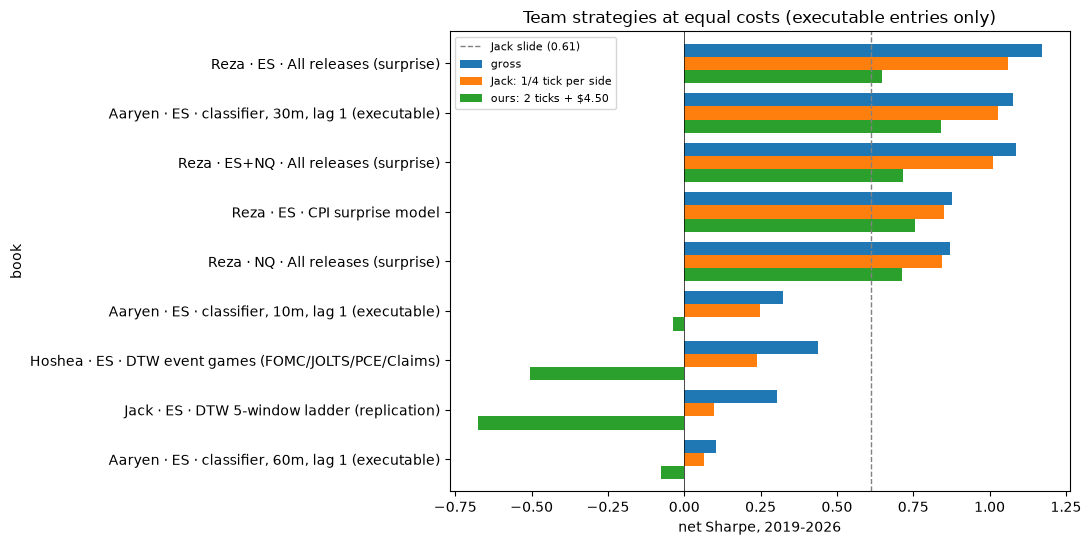

In [10]:
show = [b for b in order if "lag 1" in b or "Reza" in b or "Hoshea" in b or "Jack" in b]
fig, ax = plt.subplots(figsize=(11, 0.45 * len(show) + 1.5))
x = piv.loc[show, ["gross", "Jack: 1/4 tick per side", "ours: 2 ticks + $4.50"]]
x.plot.barh(ax=ax, width=0.8)
ax.axvline(0, c="k", lw=0.5); ax.axvline(0.613, c="gray", ls="--", lw=1, label="Jack slide (0.61)")
ax.invert_yaxis(); ax.set_xlabel("net Sharpe, 2019-2026"); ax.legend(fontsize=8)
ax.set_title("Team strategies at equal costs (executable entries only)")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "nb08_team_sharpe_equal_costs.png", dpi=150); plt.show()

## 7. Summary: Reza, Jack, Hoshea, Aaryen

In [11]:
print("=" * 110)
print("TEAM COMPARISON — ES/NQ event strategies, 2019-2026, equal costs")
print("=" * 110)
for b in order:
    r = res[(res.book == b)].set_index("scenario")
    print(f"{b:<58s} {r.loc['gross','trades_per_year']:5.0f} tr/yr | Sharpe gross {r.loc['gross','sharpe']:5.2f} | "
          f"Jack cost {r.loc['Jack: 1/4 tick per side','sharpe']:5.2f} | ours {r.loc['ours: 2 ticks + $4.50','sharpe']:5.2f}")
print("\nJack · ES · DTW ladder (slide, reported at 1/4 tick per side, 2018-2026): 185 tr/yr | Sharpe 0.61")

TEAM COMPARISON — ES/NQ event strategies, 2019-2026, equal costs
Aaryen · ES · classifier, 10m, lag 0 (as reported)            55 tr/yr | Sharpe gross  2.31 | Jack cost  2.29 | ours  2.21
Aaryen · ES · classifier, 30m, lag 0 (as reported)            55 tr/yr | Sharpe gross  2.04 | Jack cost  2.03 | ours  1.97
Aaryen · ES · classifier, 60m, lag 0 (as reported)            54 tr/yr | Sharpe gross  1.85 | Jack cost  1.83 | ours  1.77
Reza · ES · All releases (surprise)                           98 tr/yr | Sharpe gross  1.17 | Jack cost  1.06 | ours  0.65
Aaryen · ES · classifier, 30m, lag 1 (executable)             55 tr/yr | Sharpe gross  1.08 | Jack cost  1.03 | ours  0.84
Reza · ES+NQ · All releases (surprise)                       195 tr/yr | Sharpe gross  1.09 | Jack cost  1.01 | ours  0.72
Reza · ES · CPI surprise model                                 9 tr/yr | Sharpe gross  0.88 | Jack cost  0.85 | ours  0.76
Reza · NQ · All releases (surprise)                           97 tr/yr | S

## 8. Interpretation and Conclusion

*Fill in after running:*

**1. At equal costs, which workstream has the highest Sharpe at an executable entry?**

**2. Aaryen:** how much of the reported performance survives the one-minute entry lag?

**3. Hoshea:** does the DTW event-game factor survive costs?

**3b. Jack:** does the replication reproduce his slide, and how does it rank at equal costs and at our cost?

**4. How much of the differences between the team's reported numbers is explained by costs and entry timing alone?**

## 9. Jack's Slide Format, One Person at a Time

Jack's slide shows each strategy as one table and one figure. Here the **same table and figure are built for every workstream**, with the same data, window, and costs:

**Table rows**
- **Net:** strategy after Jack's cost (¼ tick per side).
- **Net (our cost):** strategy after 2 ticks + $4.50 per round trip.
- **Gross:** strategy before costs.
- **Always long, same windows (net):** long in exactly the windows the strategy traded, at Jack's cost. The gap to "Net" is the value of calling the **direction**.
- **Buy + hold:** long one ES contract every day (compounded).

**Columns:** Total % (sum of daily returns, one contract), Vol (annualised), Sharpe (daily × √252, as on Jack's slide), Max DD, Beta to buy-and-hold ES, trades per year, time in market.

**Figure:** cumulative % (one contract) of the strategy gross, the strategy net, and always-long in the same windows.

Window: **2019-01 to 2026-06** for everyone, because Reza's walk-forward logs start in 2019. Jack's slide is 2018–2026, so his own numbers are shown once more at the end for reference.

In [12]:
daily_close = sc.build_daily_close(es_adj)
_in = (daily_close.index >= pd.Timestamp(EVAL_START)) & (daily_close.index <= pd.Timestamp(EVAL_END))
trading_days = daily_close.index[_in]
NY = (trading_days[-1] - trading_days[0]).days / 365.25
bh_daily = np.expm1(daily_close["logp_close"].diff()).reindex(trading_days).fillna(0.0)
MIN_PER_DAY = 23 * 60

def _daily(t, col):
    d = pd.to_datetime(t["entry_time"].dt.tz_convert("America/New_York").dt.date)
    s = t.groupby(d.to_numpy())[col].sum() / 1e4
    s.index = pd.DatetimeIndex(s.index)
    return s.reindex(trading_days, fill_value=0.0)

def _metrics(daily, compound=False):
    if compound:
        cum = (1 + daily).cumprod() - 1; dd = (1 + cum) / (1 + cum).cummax() - 1
    else:
        cum = daily.cumsum(); dd = cum - cum.cummax()
    sd = daily.std(ddof=1); m = bh_daily
    return {"Total %": cum.iloc[-1] * 100, "Vol %": sd * np.sqrt(252) * 100,
            "Sharpe": daily.mean() / sd * np.sqrt(252) if sd > 0 else np.nan,
            "Max DD %": dd.min() * 100,
            "Beta": daily.cov(m) / m.var(ddof=1) if not compound else np.nan}

def _prep(t, scenario):
    ticks, comm = SCENARIOS[scenario]
    t = t[(t["entry_time"] >= pd.Timestamp(EVAL_START, tz="UTC")) &
          (t["entry_time"] <= pd.Timestamp(EVAL_END, tz="UTC") + pd.Timedelta(days=1))].dropna(subset=["ret_bps"]).copy()
    c = np.zeros(len(t))
    for mk, g in t.groupby("market"):
        c[t["market"].eq(mk).to_numpy()] = cost_bps(g["price"], mk, ticks, comm)
    t["cost"] = np.nan_to_num(c)
    t["gross"] = t["position"] * t["ret_bps"]
    t["net"] = t["gross"] - t["position"].abs() * t["cost"]
    t["long_net"] = np.where(t["position"] != 0, t["ret_bps"] - t["cost"], 0.0)
    return t

def slide(label, hold_min, title=None):
    t = books[label]
    j, o = _prep(t, "Jack: 1/4 tick per side"), _prep(t, "ours: 2 ticks + $4.50")
    n = int((j["position"] != 0).sum())
    extra = {"Trades / yr": n / NY, "Time in market %": n * hold_min / (len(trading_days) * MIN_PER_DAY) * 100}
    series = {"Net": _daily(j, "net"), "Net (our cost)": _daily(o, "net"), "Gross": _daily(j, "gross"),
              "Always long, same windows (net)": _daily(j, "long_net")}
    tab = pd.DataFrame({k: {**_metrics(v), **extra} for k, v in series.items()}).T
    tab.loc["Always long, same windows (net)", ["Trades / yr", "Time in market %"]] = list(extra.values())
    tab.loc["Buy + hold"] = {**_metrics(bh_daily, compound=True), "Trades / yr": np.nan, "Time in market %": 100.0}
    print(title or label)
    display(tab.round(3))

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(series["Gross"].cumsum() * 100, ls="--", c="C0", label="Strategy, gross")
    ax.plot(series["Net"].cumsum() * 100, c="C0", lw=2, label="Strategy, net of costs (Jack's cost)")
    ax.plot(series["Net (our cost)"].cumsum() * 100, c="C0", lw=1, alpha=0.5, label="Strategy, net of our cost")
    ax.plot(series["Always long, same windows (net)"].cumsum() * 100, c="C1", label="Always long, same windows (net)")
    ax.axhline(0, c="k", lw=0.5); ax.grid(alpha=0.3); ax.legend(fontsize=8, loc="upper left")
    ax.set_ylabel("cumulative %, one contract")
    ax.set_title(f"{title or label}\nExposure-matched: strategy vs always-long in the same windows")
    plt.tight_layout()
    fname = "nb08_slide_" + "".join(ch if ch.isalnum() else "_" for ch in label)[:60] + ".png"
    plt.savefig(FIGURES_DIR / fname, dpi=150); plt.show()
    return tab.assign(book=label)

SLIDES = []
print(f"Trading days: {len(trading_days)} ({trading_days[0].date()} to {trading_days[-1].date()}, {NY:.2f} years)")

Trading days: 1838 (2019-01-02 to 2026-06-30, 7.49 years)


### 9.1 Reza: Macro Surprise Strategies

Entry at the close of the first bar after the release (T+1), exit 30 minutes later (T+30). Three books: CPI only, all releases on ES, and all releases on ES + NQ.

Reza · ES · All releases (surprise)


,Total %,Vol %,Sharpe,Max DD %,Beta,Trades / yr,Time in market %
Net,21.120,2.589,1.118,-3.728,-0.001,98.388,0.872
Net (our cost),13.030,2.585,0.691,-4.665,-0.001,98.388,0.872
Gross,23.295,2.591,1.233,-3.629,-0.001,98.388,0.872
"Always long, same windows (net)",-1.782,2.550,-0.096,-8.002,0.025,98.388,0.872
Buy + hold,218.296,19.765,0.902,-29.509,NaN,NaN,100.000


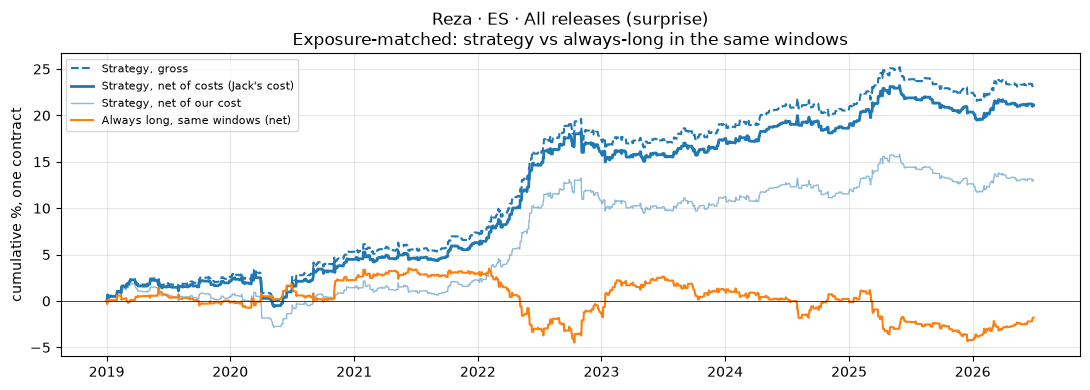

Reza · ES · CPI surprise model


,Total %,Vol %,Sharpe,Max DD %,Beta,Trades / yr,Time in market %
Net,6.240,1.013,0.844,-1.899,-0.001,8.944,0.079
Net (our cost),5.513,1.003,0.754,-2.035,-0.001,8.944,0.079
Gross,6.435,1.016,0.868,-1.863,-0.001,8.944,0.079
"Always long, same windows (net)",-3.088,1.019,-0.416,-4.121,0.007,8.944,0.079
Buy + hold,218.296,19.765,0.902,-29.509,NaN,NaN,100.000


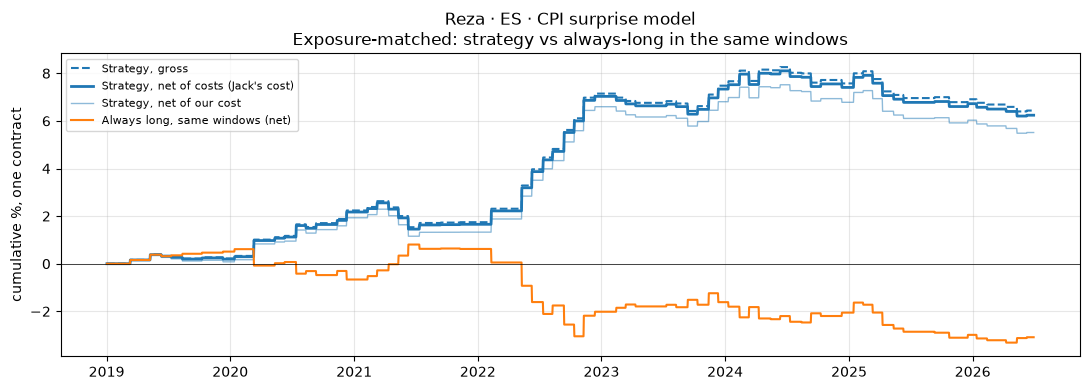

Reza · ES+NQ · All releases (surprise)


,Total %,Vol %,Sharpe,Max DD %,Beta,Trades / yr,Time in market %
Net,35.883,4.661,1.055,-6.985,0.002,195.174,1.729
Net (our cost),25.464,4.655,0.750,-7.417,0.002,195.174,1.729
Gross,38.543,4.663,1.133,-6.904,0.002,195.174,1.729
"Always long, same windows (net)",-4.317,5.687,-0.104,-18.925,0.052,195.174,1.729
Buy + hold,218.296,19.765,0.902,-29.509,NaN,NaN,100.000


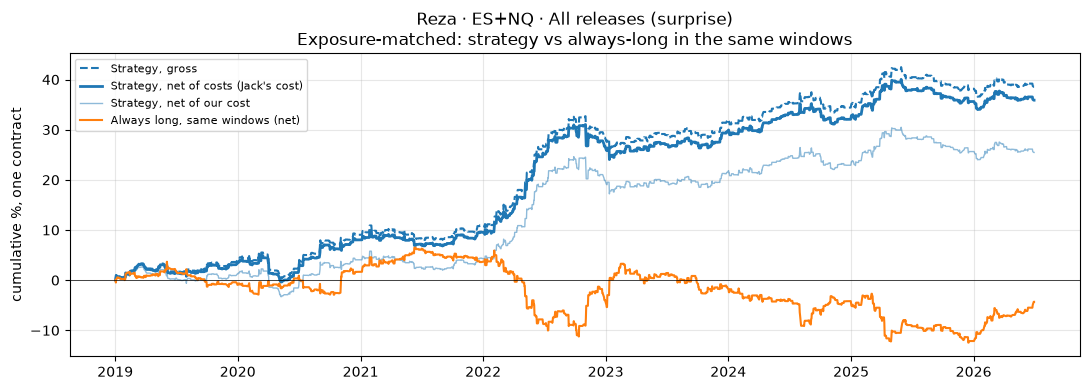

In [13]:
for b in ["Reza · ES · All releases (surprise)", "Reza · ES · CPI surprise model", "Reza · ES+NQ · All releases (surprise)"]:
    SLIDES.append(slide(b, 30))

### 9.2 Jack: DTW 5-Window Ladder (Replication)

Our rebuild of Jack's strategy from his specification (Section 5b), five 30-minute trades after each of his 8 releases.

Jack · ES · DTW 5-window ladder (replication)


,Total %,Vol %,Sharpe,Max DD %,Beta,Trades / yr,Time in market %
Net,2.390,4.456,0.074,-7.024,0.005,315.188,2.792
Net (our cost),-21.511,4.454,-0.662,-22.298,0.005,315.188,2.792
Gross,8.815,4.461,0.271,-6.849,0.005,315.188,2.792
"Always long, same windows (net)",-21.743,4.711,-0.633,-22.196,0.069,315.188,2.792
Buy + hold,218.296,19.765,0.902,-29.509,NaN,NaN,100.000


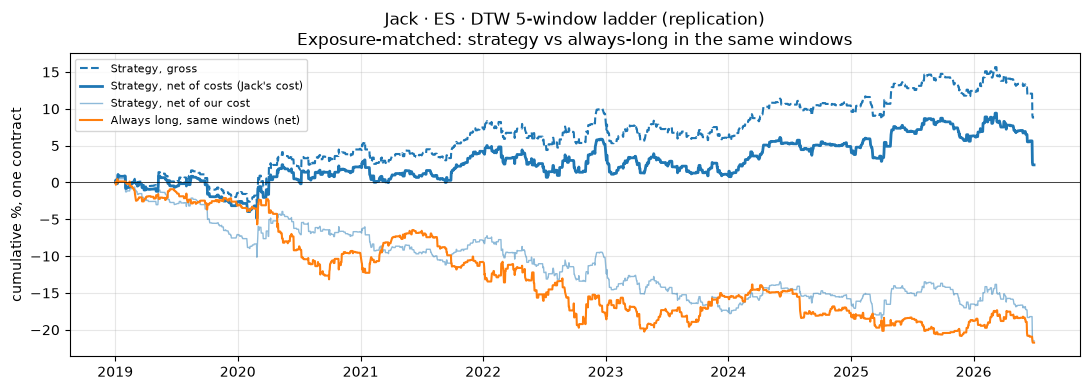

In [14]:
SLIDES.append(slide("Jack · ES · DTW 5-window ladder (replication)", 30))

### 9.3 Hoshea: DTW Event-Game Factor

Sign of Hoshea's best DTW factor (one ES contract), 30-minute trade starting at $T_0 + 60$.

Hoshea · ES · DTW event games (FOMC/JOLTS/PCE/Claims)


,Total %,Vol %,Sharpe,Max DD %,Beta,Trades / yr,Time in market %
Net,10.287,5.688,0.248,-10.063,0.010,372.192,3.298
Net (our cost),-20.560,5.674,-0.497,-24.416,0.010,372.192,3.298
Gross,18.579,5.698,0.447,-9.906,0.010,372.192,3.298
"Always long, same windows (net)",-1.688,5.518,-0.042,-20.601,0.089,372.192,3.298
Buy + hold,218.296,19.765,0.902,-29.509,NaN,NaN,100.000


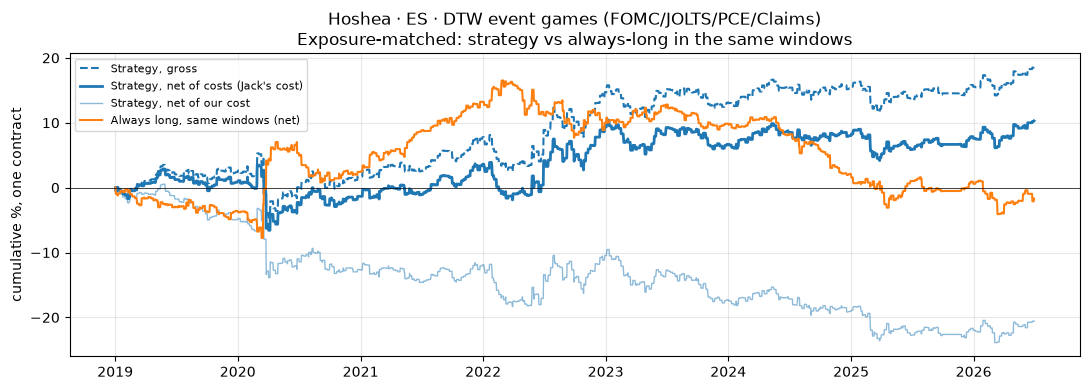

In [15]:
SLIDES.append(slide("Hoshea · ES · DTW event games (FOMC/JOLTS/PCE/Claims)", 30))

### 9.4 Aaryen: Surprise + DTW + Momentum Classifier (30-minute window)

Shown twice: **as reported** (entry at the price just before the release, lag 0) and **executable** (entry one minute later, lag 1). The difference between the two figures is the part of the profit that comes from the first-minute jump, which cannot be traded.

Aaryen · ES · classifier, 30m, lag 0 (as reported)


,Total %,Vol %,Sharpe,Max DD %,Beta,Trades / yr,Time in market %
Net,38.302,2.470,2.126,-1.451,-0.006,54.601,0.484
Net (our cost),37.021,2.455,2.067,-1.482,-0.006,54.601,0.484
Gross,38.647,2.474,2.142,-1.447,-0.006,54.601,0.484
"Always long, same windows (net)",4.170,3.742,0.153,-18.234,0.034,54.601,0.484
Buy + hold,218.296,19.765,0.902,-29.509,NaN,NaN,100.000


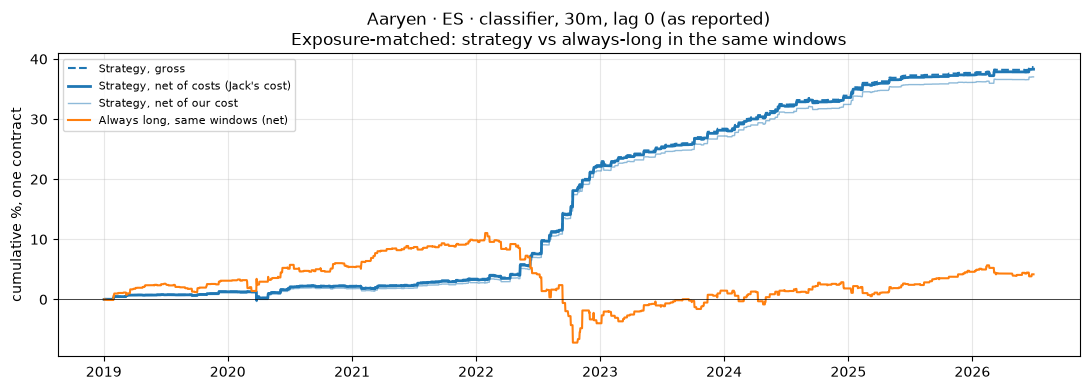

Aaryen · ES · classifier, 30m, lag 1 (executable)


,Total %,Vol %,Sharpe,Max DD %,Beta,Trades / yr,Time in market %
Net,6.928,1.082,0.878,-1.377,-0.004,54.601,0.484
Net (our cost),5.646,1.076,0.720,-1.524,-0.004,54.601,0.484
Gross,7.273,1.084,0.920,-1.355,-0.004,54.601,0.484
"Always long, same windows (net)",-1.015,2.161,-0.064,-9.822,0.017,54.601,0.484
Buy + hold,218.296,19.765,0.902,-29.509,NaN,NaN,100.000


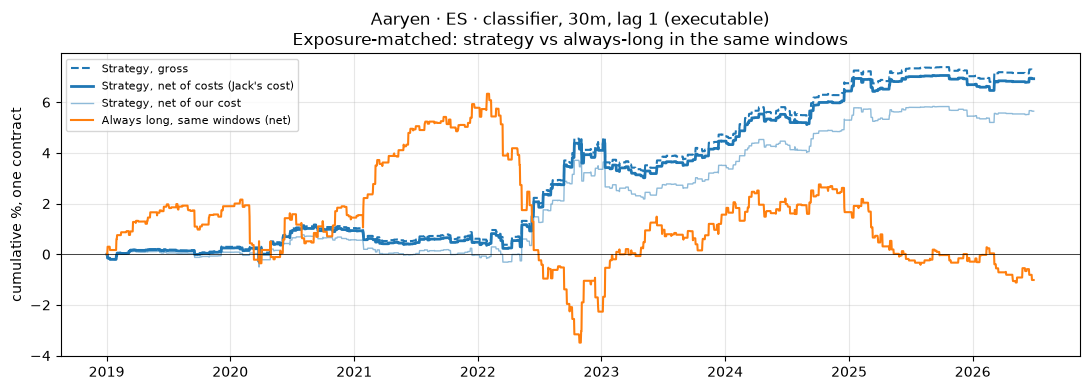

In [16]:
SLIDES.append(slide("Aaryen · ES · classifier, 30m, lag 0 (as reported)", 30))
SLIDES.append(slide("Aaryen · ES · classifier, 30m, lag 1 (executable)", 30))

### 9.5 All Slide Tables Together (Net row, Jack's cost)

In [17]:
slides = pd.concat(SLIDES)
slides.to_csv(RESULTS_DIR / "nb08_slide_format_by_person.csv")
net = slides.loc["Net"].set_index("book")
net["Sharpe (our cost)"] = slides.loc["Net (our cost)"].set_index("book")["Sharpe"]
net["Always-long Sharpe"] = slides.loc["Always long, same windows (net)"].set_index("book")["Sharpe"]
jack_slide = pd.DataFrame([{"Total %": 18.597, "Vol %": 3.020, "Sharpe": 0.613, "Max DD %": -4.928, "Beta": -0.005,
                            "Trades / yr": 185, "Time in market %": 1.4}],
                          index=["Jack · ES · DTW ladder, SLIDE (2018-26, his data)"])
print("NET (1/4 tick per side), daily Sharpe x sqrt(252), 2019-2026:")
display(pd.concat([net, jack_slide]).round(3))

NET (1/4 tick per side), daily Sharpe x sqrt(252), 2019-2026:


,Total %,Vol %,Sharpe,Max DD %,Beta,Trades / yr,Time in market %,Sharpe (our cost),Always-long Sharpe
Reza · ES · All releases (surprise),21.120,2.589,1.118,-3.728,-0.001,98.388,0.872,0.691,-0.096
Reza · ES · CPI surprise model,6.240,1.013,0.844,-1.899,-0.001,8.944,0.079,0.754,-0.416
Reza · ES+NQ · All releases (surprise),35.883,4.661,1.055,-6.985,0.002,195.174,1.729,0.750,-0.104
Jack · ES · DTW 5-window ladder (replication),2.390,4.456,0.074,-7.024,0.005,315.188,2.792,-0.662,-0.633
Hoshea · ES · DTW event games (FOMC/JOLTS/PCE/Claims),10.287,5.688,0.248,-10.063,0.010,372.192,3.298,-0.497,-0.042
"Aaryen · ES · classifier, 30m, lag 0 (as reported)",38.302,2.470,2.126,-1.451,-0.006,54.601,0.484,2.067,0.153
"Aaryen · ES · classifier, 30m, lag 1 (executable)",6.928,1.082,0.878,-1.377,-0.004,54.601,0.484,0.720,-0.064
"Jack · ES · DTW ladder, SLIDE (2018-26, his data)",18.597,3.020,0.613,-4.928,-0.005,185.000,1.400,NaN,NaN


## 10. All Four Together: Gross, Jack's Cost, Our Cost

Three figures, one per cost level. Each figure shows the **cumulative % (one contract)** of one headline strategy per person, over the same window (2019-01 to 2026-06):

| Person | Strategy shown |
|---|---|
| Reza | ES · all releases, surprise sign (T+1 → T+30) |
| Jack | ES · DTW 5-window ladder (our replication) |
| Hoshea | ES · DTW event-game factor |
| Aaryen | ES · classifier, 30-minute, **executable (lag 1)**; the as-reported lag-0 line is dotted for reference |

The legend shows each line's Sharpe (daily × √252) and total %. Under each figure, a table lists the same numbers.

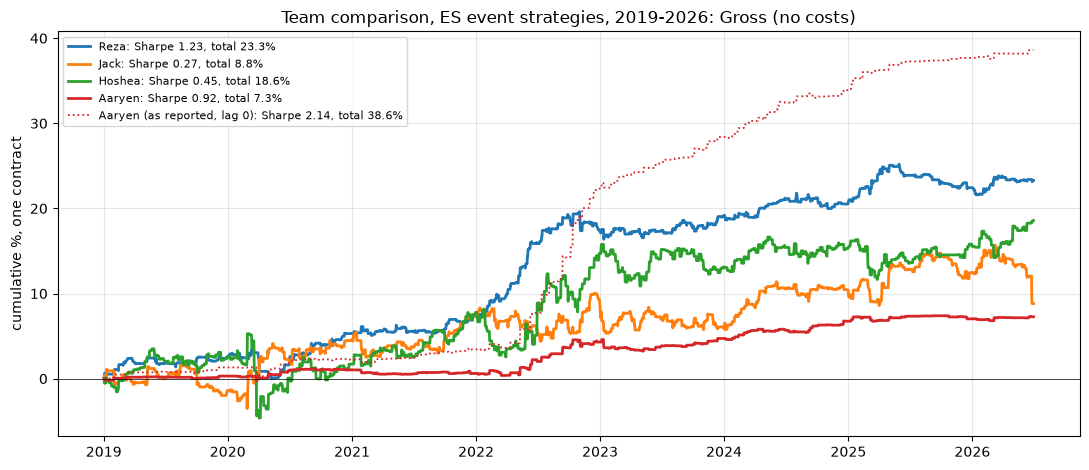

Gross (no costs)


,Total %,Vol %,Sharpe,Max DD %,Beta,Trades / yr
Reza,23.295,2.591,1.233,-3.629,-0.001,98.388
Jack,8.815,4.461,0.271,-6.849,0.005,315.188
Hoshea,18.579,5.698,0.447,-9.906,0.010,372.192
Aaryen,7.273,1.084,0.920,-1.355,-0.004,54.601
"Aaryen (as reported, lag 0)",38.647,2.474,2.142,-1.447,-0.006,54.601


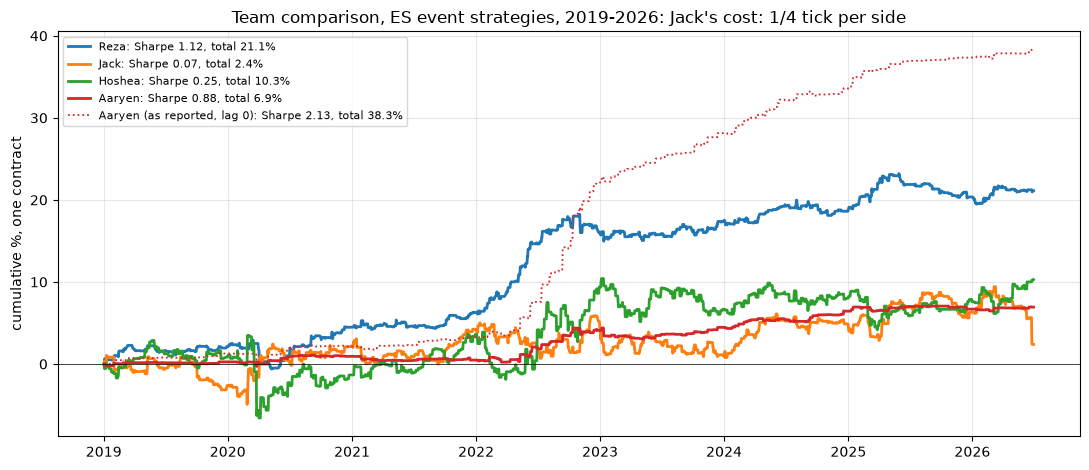

Jack's cost: 1/4 tick per side


,Total %,Vol %,Sharpe,Max DD %,Beta,Trades / yr
Reza,21.120,2.589,1.118,-3.728,-0.001,98.388
Jack,2.390,4.456,0.074,-7.024,0.005,315.188
Hoshea,10.287,5.688,0.248,-10.063,0.010,372.192
Aaryen,6.928,1.082,0.878,-1.377,-0.004,54.601
"Aaryen (as reported, lag 0)",38.302,2.470,2.126,-1.451,-0.006,54.601


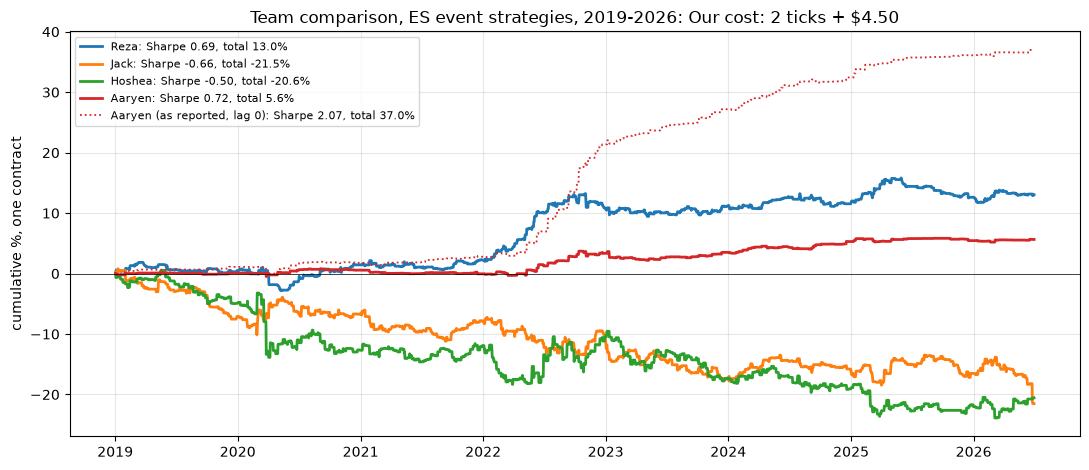

Our cost: 2 ticks + $4.50


,Total %,Vol %,Sharpe,Max DD %,Beta,Trades / yr
Reza,13.030,2.585,0.691,-4.665,-0.001,98.388
Jack,-21.511,4.454,-0.662,-22.298,0.005,315.188
Hoshea,-20.560,5.674,-0.497,-24.416,0.010,372.192
Aaryen,5.646,1.076,0.720,-1.524,-0.004,54.601
"Aaryen (as reported, lag 0)",37.021,2.455,2.067,-1.482,-0.006,54.601


In [18]:
PEOPLE = {   # person -> (book, colour, line style)
    "Reza":   ("Reza · ES · All releases (surprise)", "C0", "-"),
    "Jack":   ("Jack · ES · DTW 5-window ladder (replication)", "C1", "-"),
    "Hoshea": ("Hoshea · ES · DTW event games (FOMC/JOLTS/PCE/Claims)", "C2", "-"),
    "Aaryen": ("Aaryen · ES · classifier, 30m, lag 1 (executable)", "C3", "-"),
    "Aaryen (as reported, lag 0)": ("Aaryen · ES · classifier, 30m, lag 0 (as reported)", "C3", ":"),
}
LEVELS = {"Gross (no costs)": ("Jack: 1/4 tick per side", "gross"),
          "Jack's cost: 1/4 tick per side": ("Jack: 1/4 tick per side", "net"),
          "Our cost: 2 ticks + $4.50": ("ours: 2 ticks + $4.50", "net")}

three = []
for title, (scen, col) in LEVELS.items():
    fig, ax = plt.subplots(figsize=(11, 4.8))
    rows = {}
    for person, (book, c, ls) in PEOPLE.items():
        t = _prep(books[book], scen)
        d = _daily(t, col)
        m = _metrics(d)
        n = int((t["position"] != 0).sum())
        rows[person] = {"book": book, **m, "Trades / yr": n / NY}
        ax.plot(d.cumsum() * 100, c=c, ls=ls, lw=2 if ls == "-" else 1.3,
                label=f"{person}: Sharpe {m['Sharpe']:.2f}, total {m['Total %']:.1f}%")
    ax.axhline(0, c="k", lw=0.5); ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="upper left")
    ax.set_ylabel("cumulative %, one contract")
    ax.set_title(f"Team comparison, ES event strategies, 2019-2026: {title}")
    plt.tight_layout()
    fname = "nb08_team_cumulative_" + "".join(ch if ch.isalnum() else "_" for ch in title.split(":")[0]).strip("_") + ".png"
    plt.savefig(FIGURES_DIR / fname, dpi=150); plt.show()

    tab = pd.DataFrame(rows).T
    print(title)
    display(tab.drop(columns="book").astype(float).round(3))
    three.append(tab.assign(cost_level=title))

three = pd.concat(three)
three.to_csv(RESULTS_DIR / "nb08_team_three_cost_levels.csv")

In [19]:
# one compact table: Sharpe and total % of each person at the three cost levels
summ = three.reset_index().rename(columns={"index": "person"})
print("SHARPE (daily x sqrt(252)), 2019-2026")
display(summ.pivot(index="person", columns="cost_level", values="Sharpe")[list(LEVELS)].astype(float).round(2).loc[list(PEOPLE)])
print("TOTAL % (one contract), 2019-2026")
display(summ.pivot(index="person", columns="cost_level", values="Total %")[list(LEVELS)].astype(float).round(1).loc[list(PEOPLE)])

SHARPE (daily x sqrt(252)), 2019-2026


cost_level,Gross (no costs),Jack's cost: 1/4 tick per side,Our cost: 2 ticks + $4.50
person,,,
Reza,1.230,1.120,0.690
Jack,0.270,0.070,-0.660
Hoshea,0.450,0.250,-0.500
Aaryen,0.920,0.880,0.720
"Aaryen (as reported, lag 0)",2.140,2.130,2.070


TOTAL % (one contract), 2019-2026


cost_level,Gross (no costs),Jack's cost: 1/4 tick per side,Our cost: 2 ticks + $4.50
person,,,
Reza,23.300,21.100,13.000
Jack,8.800,2.400,-21.500
Hoshea,18.600,10.300,-20.600
Aaryen,7.300,6.900,5.600
"Aaryen (as reported, lag 0)",38.600,38.300,37.000
